In [24]:
# Installation
install.packages("tidyverse")
install.packages("scales")
library(tidyverse)
library(scales)

# Initialization
options(repr.plot.width = 9, repr.plot.height = 6)

Warning message:
"package 'tidyverse' is in use and will not be installed"
Warning message:
"package 'scales' is in use and will not be installed"


## Are we overestimating the value of magic power?

In this notebook I will attempt to get a feel for how important magic power (MP) actually is relative to other upgrades in Hypixel Skyblock in order to answer the question "Are we overestimating the value of magic power?". This question is motivated by advice I have seen both on YouTube and on the forums about how much MP is needed to play various parts of the game as well as my own experience playing these parts of the game.

One example I would like to look at to provide some context for this question is Future77's [Kuudra guide](https://youtu.be/J_KzCK1oxLs?t=157). In this guide he recommends at least $1100$ MP for T3/T4 of Kuudra, but from my experience I have done a few hundred runs with $800$-$900$ MP without much issue. This is just one example among many that has made me feel like we may be overestimating the value of MP.

To make my point more clear I would like to put this into terms of coins per stat, e.g. how many coins would I need to spend to get one more of a given stat. I will start by providing a rough example of this, applied specifically to accessories. Later I will look at this more broadly in terms of coins per damage and comparing accessories to other common upgrades.

### Coins per stat with accessories:

At the time of writing this I have $973$ MP. For this section I will be analysing intelligence as the stat. This is how much intelligence my accessories give me with $973$ MP:

In [40]:
sighted_base_intel <- 36
intel_per_tuning <- 2
curr_mp <- 973

curr_stats_mult <- 29.97 * (log((0.0019 * curr_mp) + 1) ^ 1.2)
curr_tunings <- curr_mp / 10
curr_intel <- sighted_base_intel * curr_stats_mult + intel_per_tuning * curr_tunings

print(paste("Intelligence from Sighted:", curr_intel))

[1] "Intelligence from Sighted: 1333.87424168887"


As you can see, $1333$ intelligence is not horrible, accounting for a little over $1/5^{th}$ of my total mana, but given that my next accessory upgrade costs $1.5$ million coins per MP let's see how much one more intelligence would cost:

In [47]:
new_mp <- curr_mp + 1

new_stats_mult <- 29.97 * (log((0.0019 * new_mp) + 1) ^ 1.2)
new_tunings <- new_mp / 10
new_intel <- sighted_base_intel * new_stats_mult + intel_per_tuning * new_tunings

delta_intel <- new_intel - curr_intel
coins_per_intel <- 1.5 / delta_intel

print(paste("Million Coins per Intelligence:", coins_per_intel))

[1] "Million Coins per Intelligence: 0.897536746280256"


That's pretty high. For example, with current prices, putting the $5^{th}$ star on a Fiery Aurora Chestplate is cheaper than that per mana gained, not to mention that that gives other stats like health and defense.

Warning message:
"Removed 1 row containing missing values or values outside the scale range
(`geom_line()`)."


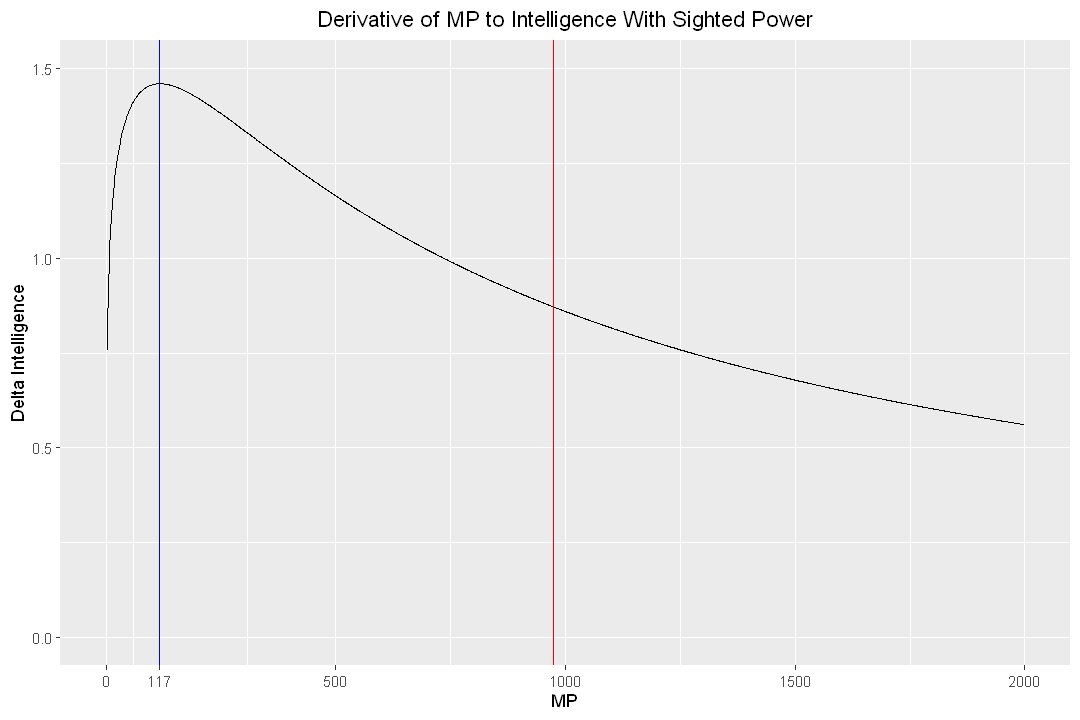

In [19]:
mp_func_vals <- data.frame(mp = c(1:2000)) |>
    mutate(stats_mult = 29.97 * (log((0.0019 * mp) + 1) ^ 1.2)) |>
    mutate(intel = sighted_base_intel * stats_mult) |>
    mutate(delta = intel - lag(intel))

mp_max_delta <- mp_func_vals[which.max(mp_func_vals$delta), ]$mp

mp_func_derivative_graph <- mp_func_vals |>
    ggplot(aes(x = mp, y = delta)) + 
    geom_line() +
    labs(title = "Derivative of MP to Intelligence With Sighted Power") +
    xlab("MP") +
    ylab("Delta Intelligence") +
    geom_vline(xintercept = mp_max_delta, color = "blue") +
    geom_vline(xintercept = curr_mp, color = "red") +
    scale_x_continuous(
        breaks = function(mp) {
            base <- pretty(mp, n = 4)
            sort(unique(c(base, mp_max_delta)))
        }
    ) + 
    scale_y_continuous(limits = c(0, 1.5)) +
    theme(plot.title = element_text(hjust = 0.5))
mp_func_derivative_graph

Importing data

In [2]:
# Import and wrangle data sources
hypixel_items <- read_tsv("data_sources/hypixel/data/items.tsv") |>
    select(id, category, rarity = tier, origin, rift_transferrable)
fandom_rarity_shorthands <- data.frame(
    shorthand = c("C", "U", "R", "E", "L", "M", "S"),
    rarity = c("COMMON", "UNCOMMON", "RARE", "EPIC", "LEGENDARY", "MYTHIC", "SPECIAL")
)
fandom_items <- read_tsv("data_sources/fandom/data/pages_table.tsv") |>
    select(id, title, unformatted_rarity = rarity, buy, upgrades_from, lower_tier, upgrades_to, higher_tier, admin_only, historical) |>
    mutate(id = str_to_upper(id)) |> # fandom has some ids in lower case
    mutate(unformatted_rarity = str_to_upper(unformatted_rarity)) |> # fandom does not have consistent casing on rarities
    left_join(fandom_rarity_shorthands, by = c("unformatted_rarity" = "shorthand")) |> # fandom sometimes uses single letter shortcuts for rarities
    mutate(rarity = coalesce(rarity, unformatted_rarity)) |>
    select(-any_of("unformatted_rarity"))
    # mutate(rift_transferrable = recode(rift_transferrable, "y" = "yes", "n" = "no")) # fandom sometimes uses "y" and "n" for "yes" and "no"
coflnet_prices <- read_tsv("data_sources/coflnet/data/prices.tsv")
magic_power <- read_tsv("data_sources/manual/data/magic_power.tsv")

# Set up constants
hegemony_artifact_multiplier <- 2
rift_prism_mp <- 11
max_contacts_no_cases <- 75 + 13 + 2 # (75) abiphone contacts trios, (13) Abiphone Flip+, (2) 9f™ Network relays

Warning message:
"One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat)"
Rows: 5380 Columns: 67
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (21): material, name, category, tier, id, salvages, description, item_mo...
dbl  (6): durability, npc_sell_price, generator_tier, gear_score, motes_sell...
lgl (40): skin, rarity_salvageable, stats, unstackable, dungeon_item_convers...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Warning message:
"One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat)"
Rows: 4658 Columns: 750
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (324): title, id, location, npcs, resources, auctionable, salable, aka, ...
dbl (1

In [3]:
### DOWNGRADES
downgrade_fandom_ids <- fandom_items |>
    filter(!is.na(id) & !is.na(title)) |>
    select(downgrade_id = id, title)

upgrade_fandom_ids <- fandom_items |>
    filter(!is.na(id) & !is.na(title)) |>
    select(upgrade_id = id, title)

items <- hypixel_items |>
    mutate(hypixel_rarity = rarity) |>
    left_join(fandom_items |> mutate(fandom_rarity = rarity), by = "id") |>
    mutate(downgrade = coalesce(upgrades_from, lower_tier)) |>
    mutate(upgrade = coalesce(upgrades_to, higher_tier)) |>
    left_join(downgrade_fandom_ids, by = c("downgrade" = "title")) |>
    left_join(upgrade_fandom_ids, by = c("upgrade" = "title")) |>
    mutate(rarity = coalesce(hypixel_rarity, fandom_rarity))

### EDGE CASES
# The fandom wiki groups all abicases into one page, seperate only the two that impact MP differently (ABICASE_SUMSUNG_1 is also the cheapest one).
abicases <- data.frame(
    id = c("ABICASE_SUMSUNG_1", "ABICASE_SUMSUNG_2"),
    category = c("ACCESSORY", "ACCESSORY"),
    rarity = c("RARE", "RARE"),
    origin = c(NA, NA),
    rift_transferrable = c(NA, NA),
    admin_only = c(FALSE, FALSE),
    downgrade_id = c(NA, "ABICASE_SUMSUNG_1"),
    upgrade_id = c("ABICASE_SUMSUNG_2", NA)
)
items <- items |>
    filter(id != "ABICASE") |>
    bind_rows(abicases)
# The Fandom Wiki does not contain info un the upgrade chain for Beastmaster Crests
items <- items |>
    mutate(downgrade_id = case_when(
        id == "BEASTMASTER_CREST_UNCOMMON" ~ "BEASTMASTER_CREST_COMMON",
        id == "BEASTMASTER_CREST_RARE" ~ "BEASTMASTER_CREST_UNCOMMON",
        id == "BEASTMASTER_CREST_EPIC" ~ "BEASTMASTER_CREST_RARE",
        id == "BEASTMASTER_CREST_LEGENDARY" ~ "BEASTMASTER_CREST_EPIC",
        TRUE ~ downgrade_id
    ))

### PRICES
items <- items |>
    mutate(npc_buy_price = str_extract(buy, "^[0-9,]+(?= Coins$)"),
        npc_buy_price = as.numeric(str_remove_all(npc_buy_price, ",")),) |>
    left_join(coflnet_prices, by = "id") |>
    mutate(price = coalesce(npc_buy_price, price, 0))

### EDGE CASES
# PARTY_HAT_SLOTH, PARTY_HAT_CRAB, PARTY_HAT_CRAB_ANIMATED are mutually exclusive and give the same stats.
items <- items |>
    filter(id == "PARTY_HAT_SLOTH" | id == "PARTY_HAT_CRAB" | id == "PARTY_HAT_CRAB_ANIMATED") |>
    slice_min(order_by = price, n = 1) |>
    bind_rows(filter(items, id != "PARTY_HAT_SLOTH" & id != "PARTY_HAT_CRAB" & id != "PARTY_HAT_CRAB_ANIMATED"))
# RUNEBOOK, PANDORAS_BOX, and BOOK_OF_PROGRESSION go up to legendary, mythic, and mythic respectively
items <- items |>
    mutate(rarity = case_when(
        id == "RUNEBOOK" ~ "LEGENDARY",
        id == "PANDORAS_BOX" ~ "MYTHIC",
        id == "BOOK_OF_PROGRESSION" ~ "MYTHIC",
        TRUE ~ rarity
    ))

### OBTAINABILITY
accessories <- items |>
    filter(category == "ACCESSORY")

accessories <- accessories |>
    filter(admin_only == FALSE) |>
    filter(is.na(historical)) |>
    filter(!(!is.na(origin) & is.na(rift_transferrable)))

### RECOMBOBULATORS
max_accessories <- accessories |>
    filter(is.na(upgrade_id))

ordered_rarities <- magic_power |>
    mutate(rarity_rank = row_number())

recombed_accessories <- max_accessories |>
    filter(!(id == "RIFT_PRISM" | id == "BOOK_OF_PROGRESSION" | id == "PANDORAS_BOX"))

recombed_accessories <- recombed_accessories |>
    mutate(downgrade_id = id)

recombed_accessories <- recombed_accessories |>
    mutate(id = paste("RECOMBED_", id,sep = ""))

recombed_accessories <- recombed_accessories |>
    left_join(ordered_rarities, by = "rarity") |>
    mutate(rarity_rank = rarity_rank + 1) |>
    select(-any_of("rarity")) |>
    left_join(ordered_rarities, by = "rarity_rank") |>
    select(-any_of("rarity_rank"))

accessories <- accessories |>
    bind_rows(recombed_accessories)

### MAGIC POWER
accessories <- accessories |>
    left_join(magic_power, by = c("rarity" = "rarity"))

### EDGE CASES
# HEGEMONY_ARTIFACT gives 2x magical power
accessories <- accessories |>
    mutate(mp = case_when(
        id == "HEGEMONY_ARTIFACT" | id == "RECOMBED_HEGEMONY_ARTIFACT" ~ mp * hegemony_artifact_multiplier,
        TRUE ~ mp
    ))
# RIFT_PRISM gives 11 magical power when consumed
accessories <- accessories |>
    mutate(mp = if_else(id == "RIFT_PRISM", rift_prism_mp, mp))
# Abicases grant 1 magical power per 2 contacts
accessories <- accessories |>
    mutate(mp = case_when(
        id == "ABICASE_SUMSUNG_1" ~ mp + floor((max_contacts_no_cases + 1) / 2),
        id == "ABICASE_SUMSUNG_2" | id == "RECOMBED_ABICASE_SUMSUNG_2" ~ mp + floor((max_contacts_no_cases + 2) / 2),
        TRUE ~ mp
    ))

### CLEANUP
accessories <- accessories |>
    select(id, price, rarity, mp, downgrade_id)

print(accessories, n = Inf)

Warning message in left_join(mutate(mutate(left_join(mutate(hypixel_items, hypixel_rarity = rarity), :
"Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 5259 of `x` matches multiple rows in `y`.
ℹ Row 48 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship =
  "many-to-many"` to silence this warning."
Warning message in left_join(left_join(mutate(mutate(left_join(mutate(hypixel_items, :
"Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 5251 of `x` matches multiple rows in `y`.
ℹ Row 689 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship =
  "many-to-many"` to silence this warning."


# A tibble: 449 × 5
    id                                           price rarity    mp downgrade_id
    <chr>                                        <dbl> <chr>  <dbl> <chr>       
  1 PARTY_HAT_SLOTH                             3.94e6 SPECI…     3 NA          
  2 TARANTULA_RING                              6.20e7 LEGEN…    16 TARANTULA_T…
  3 ARCHAEOLOGIST_COMPASS                       0      COMMON     3 NA          
  4 ANITA_TALISMAN                              1.4 e6 COMMON     3 NA          
  5 PESTHUNTER_RING                             5.98e5 RARE       8 PESTHUNTER_…
  6 ANITA_ARTIFACT                              1.18e7 RARE       8 ANITA_RING  
  7 ANITA_RING                                  4.80e6 UNCOM…     5 ANITA_TALIS…
  8 PESTHUNTER_BADGE                            1.20e5 UNCOM…     5 NA          
  9 PESTHUNTER_ARTIFACT                         1.20e6 EPIC      12 PESTHUNTER_…
 10 FISH_AFFINITY_TALISMAN                      4   e4 RARE       8 NA          
 11 FROZ

id,price,rarity,mp,downgrade_id,downgrade_price,downgrade_mp,effective_price,effective_mp,coins_per_mp,total_coins,total_mp
<chr>,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ARCHAEOLOGIST_COMPASS,0,COMMON,3,NA,NA,NA,0,3,0,0,3
FROZEN_CHICKEN,0,RARE,8,NA,NA,NA,0,8,0,0,11
FRIED_FROZEN_CHICKEN,0,EPIC,12,FROZEN_CHICKEN,0,8,0,4,0,0,15
JUNK_RING,1350000,UNCOMMON,5,JUNK_TALISMAN,1449000,3,0,2,0,0,17
RUNEBOOK,0,LEGENDARY,16,NA,NA,NA,0,16,0,0,33
PRESTIGE_CHOCOLATE_REALM,400000,LEGENDARY,16,GANACHE_CHOCOLATE_SLAB,469999,12,0,4,0,0,37
RICH_CHOCOLATE_CHUNK,199999,RARE,8,SMOOTH_CHOCOLATE_BAR,200000,5,0,3,0,0,40
SEA_CREATURE_TALISMAN,0,COMMON,3,NA,NA,NA,0,3,0,0,43
ODGERS_BRONZE_TOOTH,0,COMMON,3,NA,NA,NA,0,3,0,0,46


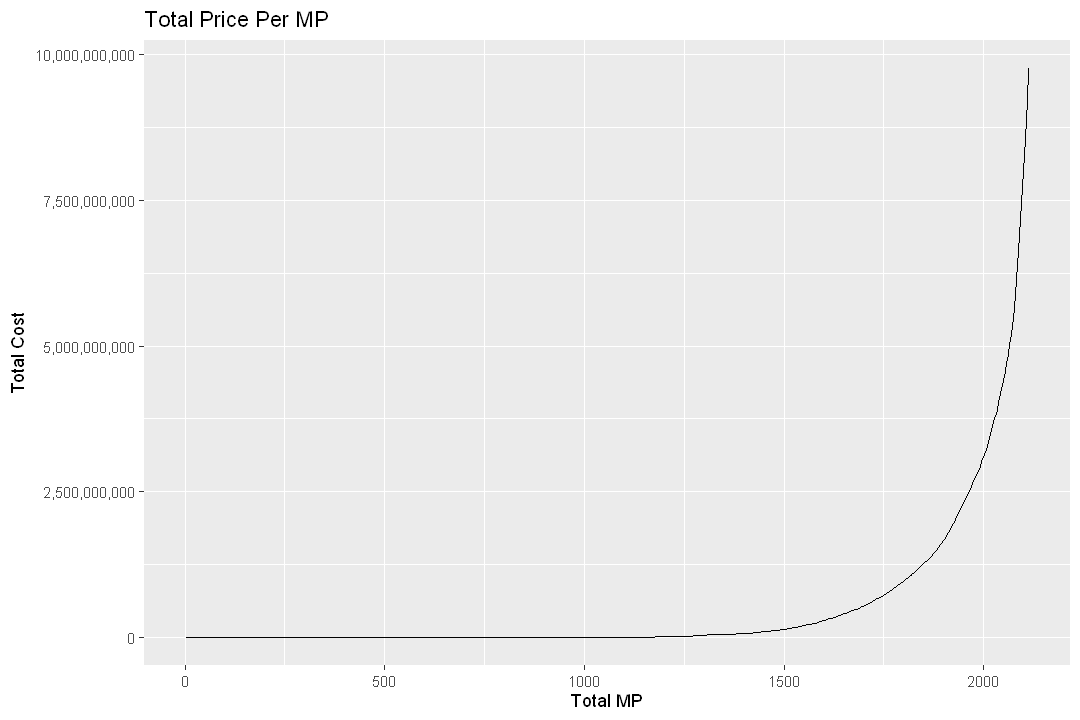

In [4]:
accessories_effective <- accessories |>
    left_join(accessories |> select(id, downgrade_price = price, downgrade_mp = mp), by = c("downgrade_id" = "id"), relationship = "many-to-many") |>
    mutate(effective_price = price - coalesce(downgrade_price, 0)) |>
    mutate(effective_price = if_else(effective_price > 0, effective_price, 0)) |>
    mutate(effective_mp = mp - coalesce(downgrade_mp, 0)) |>
    mutate(effective_mp = if_else(effective_mp > 0, effective_mp, 0))
# accessories_effective

coins_per_mp <- accessories_effective |>
    mutate(coins_per_mp = effective_price / effective_mp) |>
    arrange(coins_per_mp) |>
    mutate(total_coins = cumsum(effective_price)) |>
    mutate(total_mp = cumsum(effective_mp))
coins_per_mp

coins_per_mp_graph <- coins_per_mp |>
    ggplot(aes(x = total_mp, y = total_coins)) +
    geom_line() +
    scale_y_continuous(labels = comma) +
    labs(title = "Total Price Per MP") +
    xlab("Total MP") +
    ylab("Total Cost")
coins_per_mp_graph

In [5]:
fandom_data <- read_tsv("data_sources/fandom/data/pages_table.tsv") |>
    select(id, title, type, upgrades_from, buy)

real_accessories <- accessories |>
    left_join(fandom_data, by = c("id" = "id")) |>
    mutate(buy_price = str_extract(buy, "^[0-9,]+(?= Coins$)"),
        buy_price = as.numeric(str_remove_all(buy_price, ",")),) |>
    mutate(real_price = coalesce(buy_price, price, 0)) |>
    filter(id == "SCAVENGER_TALISMAN")
real_accessories

Warning message:
"One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat)"
Rows: 4658 Columns: 750
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (324): title, id, location, npcs, resources, auctionable, salable, aka, ...
dbl (167): enigma_souls, museum_xp, base_value, fairy_souls, helmet_health, ...
num   (1): organicmatter
lgl (258): admin_only, appearance, farming_wisdom, historical, tiered_bonus2...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Warning message in left_join(accessories, fandom_data, by = c(id = "id")):
"Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 284 of `x` matches multiple rows in `y`.
ℹ Row 3146 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship =
  "many-to-ma

id,price,rarity,mp,downgrade_id,title,type,upgrades_from,buy,buy_price,real_price
<chr>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>
SCAVENGER_TALISMAN,10000,COMMON,3,NA,Scavenger Talisman,NA,NA,"10,000 Coins",10000,10000
